<a href="https://colab.research.google.com/github/SHINE51278/AIDL_labassignments/blob/main/AIDL_labassignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
X = torch.tensor([[1,0,120,8.5],
                 [0,1,95,7.2],
                 [1,1,110,8.0],
                 [0,0,90,5.5],
                 [1,0,85,6.0],
                 [0,1,130,6.2]],dtype = torch.float32)
y = torch.tensor([[1],[1],[1],[0],[0],[0]],dtype=torch.float32)
print('Input:')
print(X)
print('Output:')
print(y)

Input:
tensor([[  1.0000,   0.0000, 120.0000,   8.5000],
        [  0.0000,   1.0000,  95.0000,   7.2000],
        [  1.0000,   1.0000, 110.0000,   8.0000],
        [  0.0000,   0.0000,  90.0000,   5.5000],
        [  1.0000,   0.0000,  85.0000,   6.0000],
        [  0.0000,   1.0000, 130.0000,   6.2000]])
Output:
tensor([[1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.]])


In [4]:
X_mean=X.mean(dim=0)
X_std=X.std(dim=0)
X_norm=(X-X_mean)/X_std
print('Normalized Input:')
print(X_norm)

Normalized Input:
tensor([[ 0.9129, -0.9129,  0.8385,  1.3408],
        [-0.9129,  0.9129, -0.5590,  0.2514],
        [ 0.9129,  0.9129,  0.2795,  0.9218],
        [-0.9129, -0.9129, -0.8385, -1.1732],
        [ 0.9129, -0.9129, -1.1180, -0.7542],
        [-0.9129,  0.9129,  1.3975, -0.5866]])


In [5]:
class MovieModel(nn.Module):
    def __init__(self):
        super(MovieModel,self).__init__()
        self.network=nn.Sequential(
            nn.Linear(4,8),
            nn.ReLU(),
            nn.Linear(8,4),
            nn.ReLU(),
            nn.Linear(4,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.network(x)


In [10]:
M_sgd=MovieModel()
criterian=nn.BCELoss()
optimizer=optim.SGD(M_sgd.parameters(),lr=0.01)
sgd_loss=[]
for epoch in range(1000):
    y_pred=M_sgd(X_norm)
    loss=criterian(y_pred,y)
    # The error was here, appending twice per epoch
    # sgd_loss.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    sgd_loss.append(loss.item())
    if (epoch+1)%100==0:
        print(f'SGD Epoch:[{epoch+1}/1000], Loss:{loss.item():.4f}')
print('SGD Loss:')
print(sgd_loss)

SGD Epoch:[100/1000], Loss:0.7024
SGD Epoch:[200/1000], Loss:0.6743
SGD Epoch:[300/1000], Loss:0.6531
SGD Epoch:[400/1000], Loss:0.6289
SGD Epoch:[500/1000], Loss:0.5953
SGD Epoch:[600/1000], Loss:0.5461
SGD Epoch:[700/1000], Loss:0.4763
SGD Epoch:[800/1000], Loss:0.3896
SGD Epoch:[900/1000], Loss:0.3004
SGD Epoch:[1000/1000], Loss:0.2185
SGD Loss:
[0.7838075757026672, 0.7823945879936218, 0.7810018658638, 0.7796290516853333, 0.7782757878303528, 0.7769415974617004, 0.7756261229515076, 0.7743290066719055, 0.7730497717857361, 0.7717881798744202, 0.7705438733100891, 0.7693163752555847, 0.7681055068969727, 0.7669108510017395, 0.7657321095466614, 0.7645688652992249, 0.7634210586547852, 0.7622880935668945, 0.7611699104309082, 0.760066032409668, 0.7589762806892395, 0.7579002976417542, 0.7568380236625671, 0.7557889819145203, 0.7547529339790344, 0.7537296414375305, 0.752718985080719, 0.7517206072807312, 0.7507343292236328, 0.7497597336769104, 0.7487968802452087, 0.747845470905304, 0.746905088424

In [12]:
M_adam=MovieModel() # Initialize M_adam
criterian=nn.BCELoss()
optimizer=optim.Adam(M_adam.parameters(),lr=0.01) # Changed optim.adam to optim.Adam
adam_loss=[]
for epoch in range(1000):
    y_pred=M_adam(X_norm)
    loss=criterian(y_pred,y)
    # The error was here, appending twice per epoch
    # sgd_loss.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    adam_loss.append(loss.item())
    if (epoch+1)%100==0:
        print(f'Adam Epoch:[{epoch+1}/1000], Loss:{loss.item():.4f}') # Changed SGD Epoch to Adam Epoch
print('Adam Loss:')
print(adam_loss)

Adam Epoch:[100/1000], Loss:0.0028
Adam Epoch:[200/1000], Loss:0.0008
Adam Epoch:[300/1000], Loss:0.0004
Adam Epoch:[400/1000], Loss:0.0002
Adam Epoch:[500/1000], Loss:0.0002
Adam Epoch:[600/1000], Loss:0.0001
Adam Epoch:[700/1000], Loss:0.0001
Adam Epoch:[800/1000], Loss:0.0001
Adam Epoch:[900/1000], Loss:0.0001
Adam Epoch:[1000/1000], Loss:0.0000
Adam Loss:
[0.7331101894378662, 0.7226977944374084, 0.7149534225463867, 0.7077531814575195, 0.7007346153259277, 0.6938626170158386, 0.687083899974823, 0.6803334355354309, 0.673910915851593, 0.667706310749054, 0.6613054871559143, 0.6562979817390442, 0.651027500629425, 0.6451074481010437, 0.6391710042953491, 0.6318681836128235, 0.6234931945800781, 0.6140294671058655, 0.6036056876182556, 0.5921881198883057, 0.5796070694923401, 0.5672504901885986, 0.5533469319343567, 0.5386995673179626, 0.5232968926429749, 0.5074930191040039, 0.4906381070613861, 0.4727935791015625, 0.4541657865047455, 0.4346355199813843, 0.41577017307281494, 0.39603206515312195,

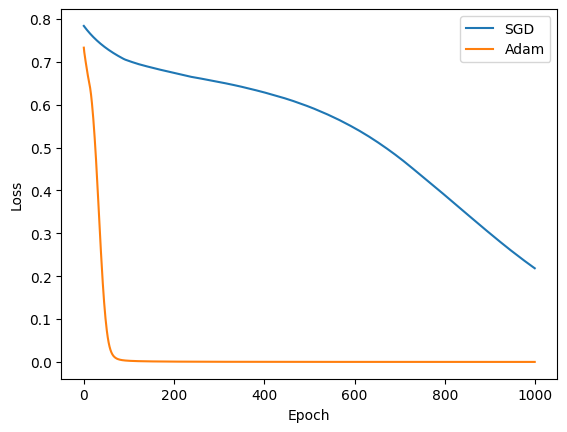

In [13]:
import matplotlib.pyplot as plt
plt.plot(sgd_loss,label='SGD')
plt.plot(adam_loss,label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()